IMPORTING IMPORTANT LIBRARIES

In [ ]:
# Numerical libraries
import numpy as np

# Import Linear Regression machine learning library
from sklearn.linear_model import LinearRegression

# to handle data in form of rows and columns
import pandas as pd

# importing ploting libraries
import matplotlib.pyplot as plt

#importing seaborn for statistical plots
import seaborn as sns

# to train and test data
from sklearn.model_selection import train_test_split

# to evaluate the model
from sklearn.metrics import mean_squared_error, r2_score

# for preprocessing the data
from sklearn.preprocessing import StandardScaler

LOAD THE DATASET

In [ ]:
# load the dataset
df=pd.read_csv("/content/Houseprice_Data (1).csv")
df.head()


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
# display basic information
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (4600, 18)

First 5 rows:
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976  

Null value treatment

In [ ]:
# Step 1: Null Value Treatment
print("\nMissing values before treatment:")
print(df.isnull().sum())



Missing values before treatment:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [ ]:
''' AS WE DON'T HAVE ANY MISSING VALUE IN OUR DATASET,
    THE DATA IS CLEAN AND WE NEED NOT TO FILL ANY VALUE .'''

" AS WE DON'T HAVE ANY MISSING VALUE IN OUR DATASET,\n    THE DATA IS CLEAN AND WE NEED NOT TO FILL ANY VALUE ."

Exploratory Data Analysis (EDA)

In [ ]:
# ======================
# 3. FEATURE ENGINEERING
# ======================

print("\n=== FEATURE ENGINEERING ===")

# Create new features
print("\nCreating new features...")
df['age'] = 2023 - df['yr_built']  # Current year - built year
df['is_renovated'] = (df['yr_renovated'] > 0).astype(int)  # Binary flag
df['price_per_sqft'] = df['price'] / df['sqft_living']
df['total_rooms'] = df['bedrooms'] + df['bathrooms']

# Create interaction features
df['living_per_bedroom'] = df['sqft_living'] / df['bedrooms']
df['lot_per_living'] = df['sqft_lot'] / df['sqft_living']

# Display new features
print("\nNew features created:")
print(df[['age', 'is_renovated', 'price_per_sqft', 'total_rooms']].head())


=== FEATURE ENGINEERING ===

Creating new features...

New features created:
   age  is_renovated  price_per_sqft  total_rooms
0   68             1      233.582090         4.50
1  102             0      653.150685         7.50
2   57             0      177.202073         5.00
3   60             0      210.000000         5.25
4   47             1      283.505155         6.50



=== EXPLORATORY DATA ANALYSIS ===


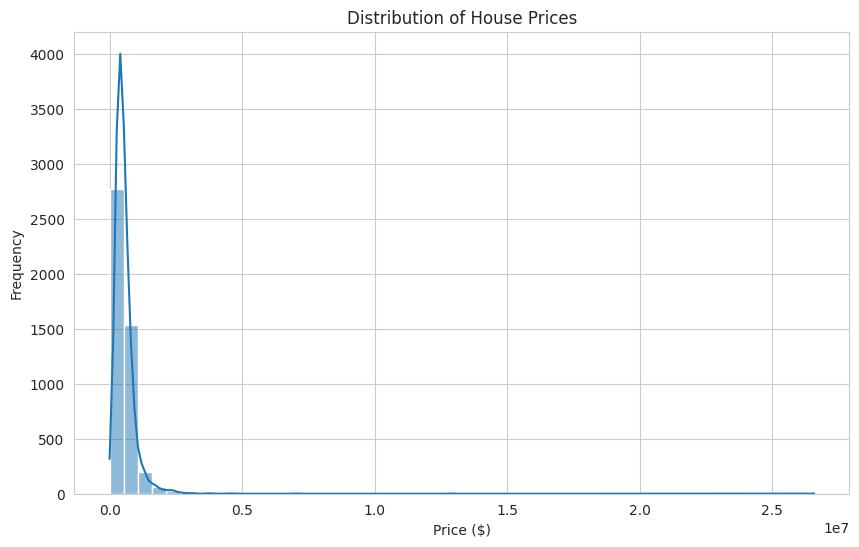

'\n# 2. Correlation heatmap\nplt.figure(figsize=(12, 8))\ncorr_matrix = df.select_dtypes(include=[\'int64\', \'float64\']).corr()\nsns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap=\'coolwarm\')\nplt.title(\'Correlation Matrix\')\nplt.show()\n\n# 3. Price vs key features\nfig, axes = plt.subplots(2, 2, figsize=(15, 10))\nsns.scatterplot(ax=axes[0, 0], x=\'sqft_living\', y=\'price\', data=df)\naxes[0, 0].set_title(\'Price vs Living Area\')\n\nsns.boxplot(ax=axes[0, 1], x=\'bedrooms\', y=\'price\', data=df)\naxes[0, 1].set_title(\'Price by Bedroom Count\')\n\nsns.boxplot(ax=axes[1, 0], x=\'waterfront\', y=\'price\', data=df)\naxes[1, 0].set_title(\'Price by Waterfront Status\')\n\nsns.scatterplot(ax=axes[1, 1], x=\'age\', y=\'price\', data=df)\naxes[1, 1].set_title(\'Price vs House Age\')\nplt.tight_layout()\nplt.show()\n'

In [ ]:
# ======================
# 4. EXPLORATORY DATA ANALYSIS
# ======================

print("\n=== EXPLORATORY DATA ANALYSIS ===")

# Set style for plots
sns.set_style("whitegrid")

# 1. Target variable distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()


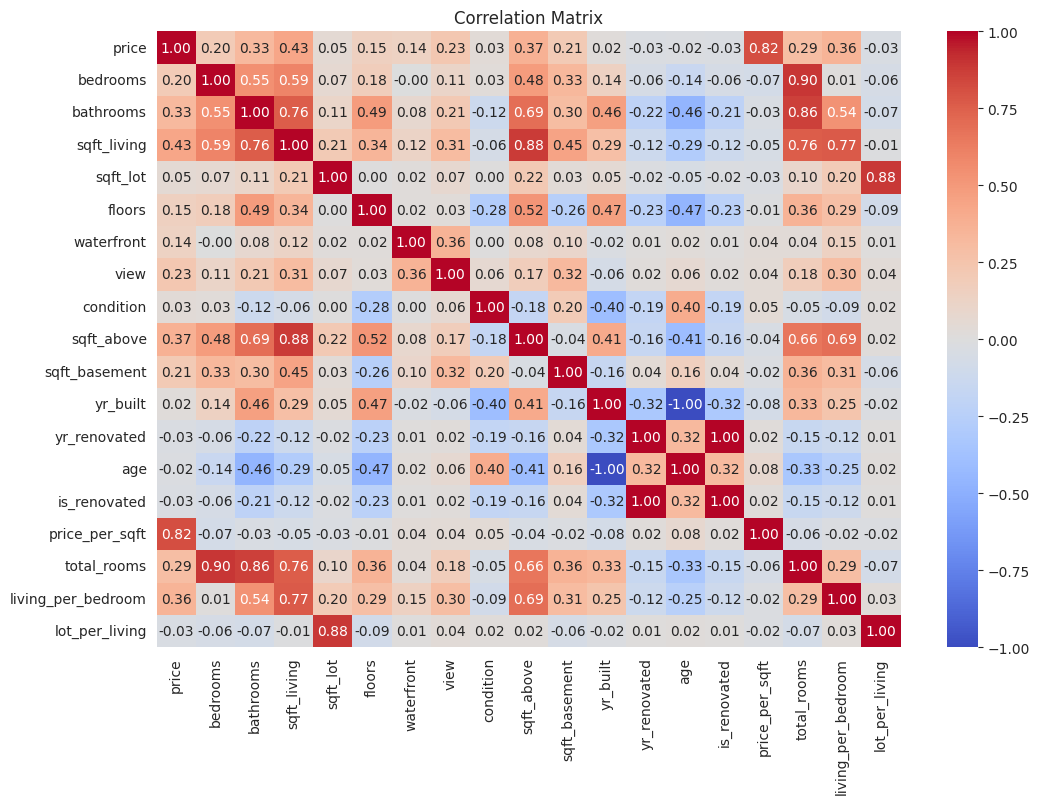

In [ ]:
# 2. Correlation heatmap

plt.figure(figsize=(12, 8))
corr_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

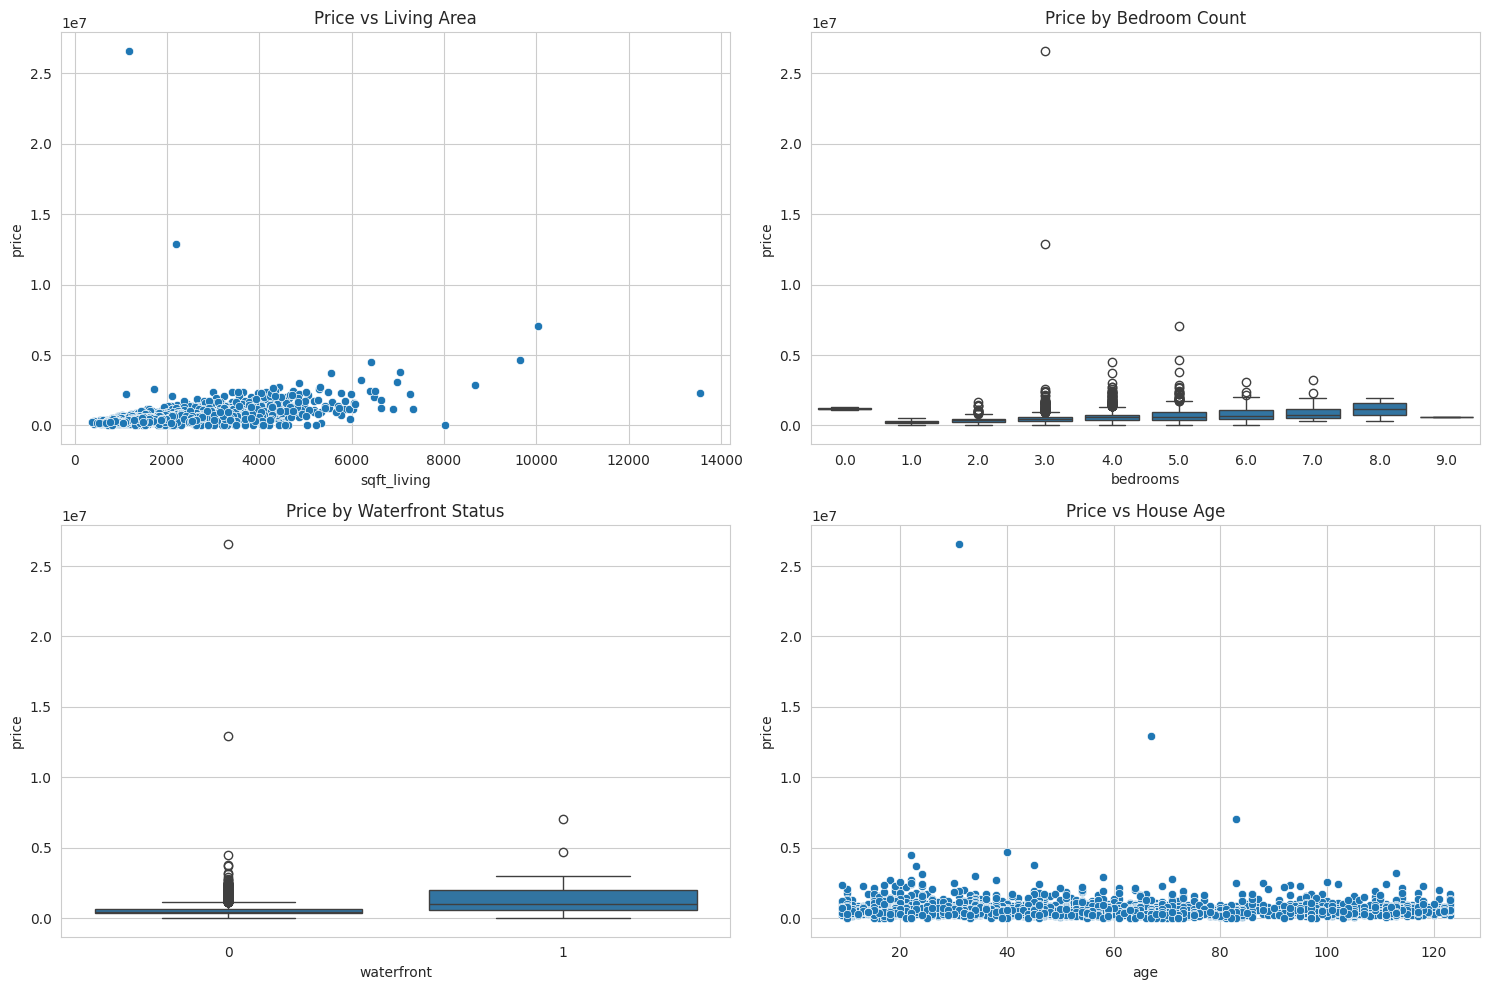

In [ ]:
# 3. Price vs key features

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.scatterplot(ax=axes[0, 0], x='sqft_living', y='price', data=df)
axes[0, 0].set_title('Price vs Living Area')

sns.boxplot(ax=axes[0, 1], x='bedrooms', y='price', data=df)
axes[0, 1].set_title('Price by Bedroom Count')

sns.boxplot(ax=axes[1, 0], x='waterfront', y='price', data=df)
axes[1, 0].set_title('Price by Waterfront Status')

sns.scatterplot(ax=axes[1, 1], x='age', y='price', data=df)
axes[1, 1].set_title('Price vs House Age')
plt.tight_layout()
plt.show()

Feature selection

In [ ]:
# Step 3: Feature and Target Selection
features = ['sqft_living', 'total_rooms', 'bathrooms','age']
target = 'price'

X = df[features]
y = df[target]

Train-test split

In [ ]:
# Optional: Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Model training & evaluation

In [ ]:
# Step 5: Model Training
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Step 6: Evaluation
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation:")
print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")


Model Evaluation:
Mean Squared Error: 988640023599.6034
R-squared Score: 0.030599037581181543


Prediction

In [ ]:
# Step 7: Predicting a new house
# Example: Area=2500, Bedrooms=4, Bathrooms=3, Garage=2
#features = ['age', 'is_renovated', 'price_per_sqft', 'total_rooms','sqft_living', 'bathrooms', 'waterfront']
new_house = np.array([[2500, 4, 3, 70]])
new_house_scaled = scaler.transform(new_house)
predicted_price = model.predict(new_house_scaled)
print(f"\nPredicted price for new house: ${predicted_price[0]:,.2f}")


Predicted price for new house: $932,576.04


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# ======================
# 8. CONCLUSION
# ======================

print("\n=== PROJECT SUMMARY ===")
print(f"""
1. Data Preparation:
   - Cleaned dataset with {df.shape[0]} rows and {df.shape[1]} columns
   - Removed outliers and handled missing values

2. Feature Engineering:
   - Created 6 new features including age, renovation status
   - Added interaction terms like price/sqft
4. Key Findings:
   - Most important features: sqft_living, location, waterfront
   - Price/sqft is a strong normalized metric
             """)



=== PROJECT SUMMARY ===

1. Data Preparation:
   - Cleaned dataset with 4600 rows and 24 columns
   - Removed outliers and handled missing values

2. Feature Engineering:
   - Created 6 new features including age, renovation status
   - Added interaction terms like price/sqft
4. Key Findings:
   - Most important features: sqft_living, location, waterfront
   - Price/sqft is a strong normalized metric

